In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score

## Conjunto de datos
Dataset: https://www.kaggle.com/datasets/juanagsolano/penguins-v1

In [54]:
pin = pd.read_csv('penguins_v1.csv')
df = pd.DataFrame(pin)
df.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,1,1,39.1,18.7,181,3750,1,2007
1,2,1,1,39.5,17.4,186,3800,0,2007
2,3,1,1,40.3,18.0,195,3250,0,2007
3,5,1,1,36.7,19.3,193,3450,0,2007
4,6,1,1,39.3,20.6,190,3650,1,2007


### Tipos de datos
Se exploran los tipos de datos de cada variable del conjunto de datos. Se tiene un total de 8 variables, todas numericas, donde se indica la especie del pingüino donde  1 = "Adelie", 2 = "Gentoo", 3 = "Chinstrap", se indica la isla de donde proviene donde  1 = "Torgersen", 2 = "Biscoe", 3 = "Dream", longitud del pico en mm, profundidad del pico en mm, longitud de la aleta en mm, peso en gramos, y año en que se tomo la medición.

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 333 non-null    int64  
 1   species            333 non-null    int64  
 2   island             333 non-null    int64  
 3   bill_length_mm     333 non-null    float64
 4   bill_depth_mm      333 non-null    float64
 5   flipper_length_mm  333 non-null    int64  
 6   body_mass_g        333 non-null    int64  
 7   sex                333 non-null    int64  
 8   year               333 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 23.5 KB


### Variable objetivo
Se elige como variable objetivo o variable dependiente a "specias", de manera que el resto de las variables son los valores de X, es decir, las variables independientes.
Se establece la columna de y. Se establecen las columnas para X usando drop para eliminar la variable objetivo

In [56]:
y = df['species']
X = df.drop(columns=['species'])

### Revisar valores nulos
Se hace la revisión de la existencia de valores nulos en los datos. Se usa la función insull la cual detecta si hay valores nulos del tipo NaN o None en un DataFrame o una serie, si es nulo entonces devuelve True, de lo contrario devuelve False. También, se usa sum() que devuelve la sumatoria de un iterable.

In [57]:
df.isnull().sum()

id                   0
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

## División de datos
Se hace la división de datos de entrenamiento y de prueba usando la función train_test_split, la cual devuelve el conjunto de entrenamiento para X, el conjunto de prueba para X, el conjunto de entrenamiento para y, el conjunto de prueba para y. En este caso, se usa el tamaño de entrenamiento del 80% del total de los datos y el restante 20% para entrenarlo. Recibe como parámetro a las variables independientes, la vaariable dependiente, el tamaño de prueba, y la semilla aleatoria.

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

Muestras de entrenamiento: 266
Muestras de prueba: 67


## Estandarización de los datos
Se hace la estandarización de los datos para eliminar la influencia de las magnitudes. Se manda a llamar la clase StandardScaler, y se manda a llamar al método scaler.fit_transform para transformar al conjunto de entrenamiento, mientras que scaler.transform transforma al conjunto de prueba. En ambos se especifica que solo es para datos númericos.

In [59]:
scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train.select_dtypes(include=['number']))
X_test_escalado = scaler.transform(X_test.select_dtypes(include=['number']))

## Correlación
Se realiza la matriz de correlación y se grafica como mapa de calor para que se pueda visualizar de mejor manera. SLa correlación de pearson es una medida de la relación lineal entre dis variables aleatorias X, Y.   
$$\rho (X, Y) = \frac{E[(X - \mu x)(Y - \mu y)]}{\sigma x \sigma y}$$
Donde:  
$E[(X - \mu x)(Y - \mu y)$: Covarianza de X, Y    
$\mu x, \mu y$ Son las medias de X, Y    
$\sigma x, \sigma y$ Son las desviaciones estándar    

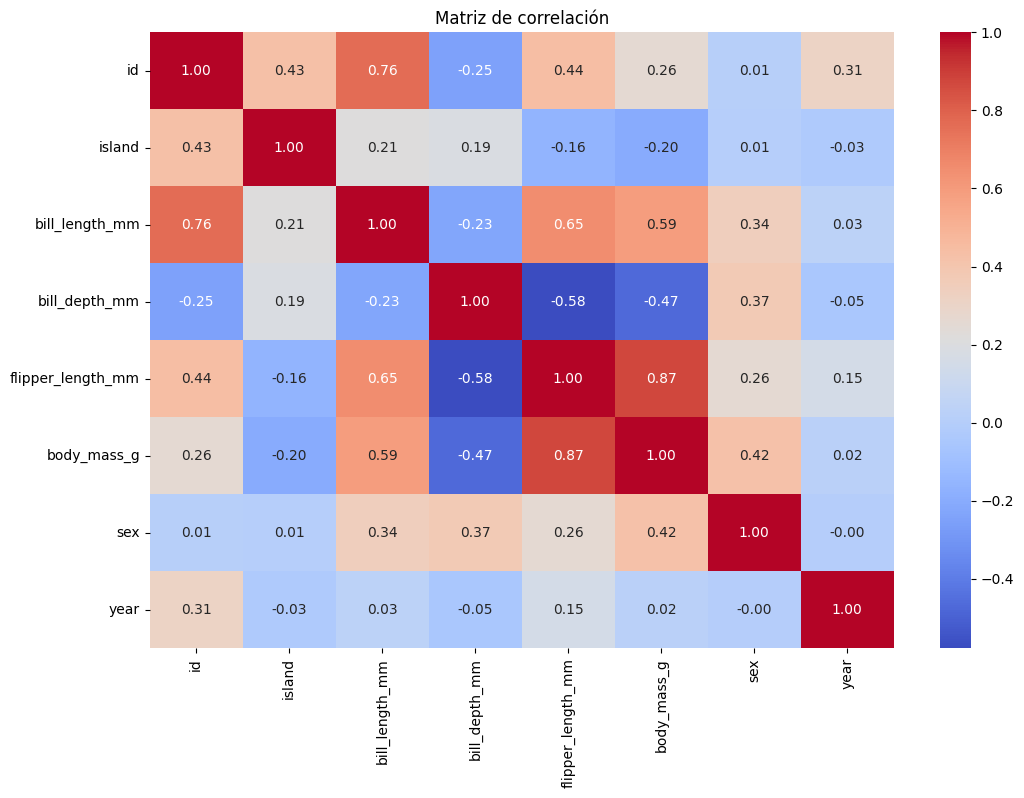

In [60]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación')
plt.show()

## Árbol de desición
Los árboles de desición y bosques aleatorios son algoritmos basados en reglas para aproximizar relaciones en datos estructurados.

In [61]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
y_pred = clf.predict(X_test)

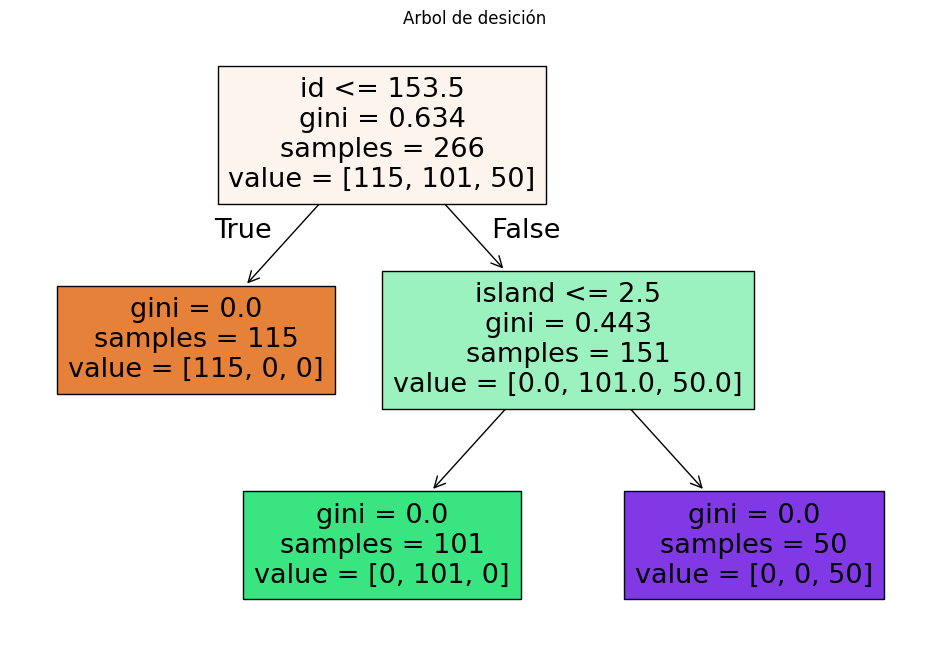

In [63]:
plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=X_train.columns)
plt.title('Arbol de desición')
plt.show()

## Métricas
Precisión: Mide que tan preciso es el modelo al hacer predicciones positivas.
$$Precision=\frac{True Positive}{True Positive + False Positive}$$
True Positive: Casos correctamente clasificados como positivos.    
False Positive: Casos incorrectamente clasificados como positivos.    
Sensibilidad o exhaustividad (Recall): Mide qué porcentaje de los casos positivos fueron detectados correctamente.   
$$Recall = \frac{True Positive}{True Positive + False Negatives}$$
False Negative: Casos positivos en que el modelo clasificó como negativos.   
F1- Score: Métrica combinada que busca equilibrar la presición y el recall.  
$$F1 = 2(\frac{(Precision)(Recall)}{(Precision + Recall)})$$
Suport: Indica el número de instancias reales de cada clase en los datos de prueba.

In [64]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
support = df['species'].value_counts()
print(f'Precisión: {precision:.2f}')
print(f'Recall: {recall}')
print(f'F1: {f1}')
print(f'Support: {support}')

Precisión: 0.99
Recall: 0.9850746268656716
F1: 0.9849798625918028
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


## Criterios
Medidas usadas para decidir como dividir los datos en ramas. 
### Criterio Gini
Revisa la frecuencia con la que una muestra aleatoria se etiquetaria de manera incorrecta si se asignara por probabilidad de clase. 
$$Gini = 1 -\sum_{i=1}^n p_ilog_2(p_i)$$
$p_i$: Probabilidad de la clase
Entre menor sea el valor del nodo, entonces los nodos son más homogéneos.
### Entropía
Mide la incertidumbre en la distribución de clases de un nodo. Entre mayor entropía hay mayor desorden entre las etiquetas de clase.
$$Entropia = -\sum_{i=1}^n p_i log_2(p_i)$$

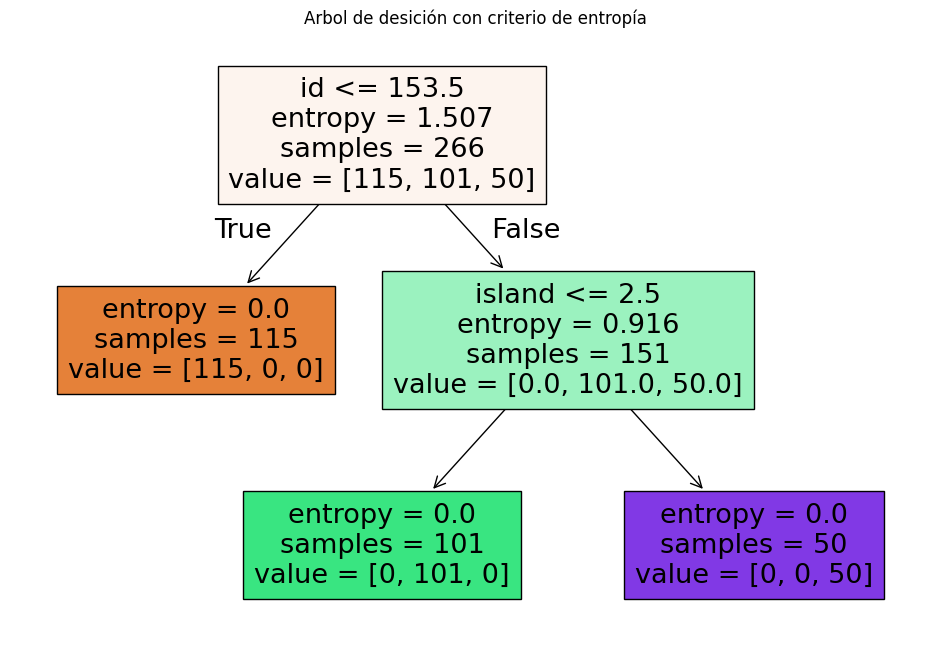

Precisión: 0.99
Recall: 0.9850746268656716
F1: 0.9849798625918028
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [65]:
clf_entropia = DecisionTreeClassifier(criterion='entropy')
clf_entropia.fit(X_train, y_train)
y_pred_entropia = clf_entropia.predict(X_test)

plt.figure(figsize=(12,8))
plot_tree(clf_entropia, filled=True, feature_names=X_train.columns)
plt.title('Arbol de desición con criterio de entropía')
plt.show()

precision_entropia = precision_score(y_test, y_pred_entropia, average='weighted')
recall_entropia = recall_score(y_test, y_pred_entropia, average='weighted')
f1_entropia = f1_score(y_test, y_pred_entropia, average='weighted')
support = df['species'].value_counts()
print(f'Precisión: {precision_entropia:.2f}')
print(f'Recall: {recall_entropia}')
print(f'F1: {f1_entropia}')
print(f'Support: {support}')

## Conclusión
Para concluir, se puede observar que el primer árbol de decisión que tiene como default el criterio de Gini tiene mayor precisión comparado con el segundo árbol de decisión que usa como criterio a la entropía. También,el primero tiene mayor sensibilidad y puntuación de F1, aunque esta variación solo es por décimas. 